In [13]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.measure import profile_line
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from pathlib import Path
from datetime import datetime
import matplotlib.dates as mdates ## Import required library
import sys
from scipy.optimize import curve_fit
sys.path.append('/Users/coletamburri/Desktop/Flare_Patrol_Analysis/WORKING_SOURCE/')
import dkistpkg_ct as DKISTanalysis
from scipy.ndimage import map_coordinates
from datetime import datetime, timedelta
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy.signal import peak_widths



In [14]:
# get times and Fried parameter for entire series
vbi_filenames=[]

path = '/Volumes/ViSP_External/pid_2_11_VBI/MBVIDS'
# Specify the directory
folder = Path(path)

# List all files and folders
for item in folder.iterdir():
    if item.is_file():
        
        vbi_filenames.append(item.name)

vbi_filenames.sort()
del vbi_filenames[0:3]
vbi_filenames
timesvbi=[]
friedvbi=[]

for i in range(len(vbi_filenames)-1):
    timesvbi.append(fits.open(path+'/'+vbi_filenames[i])[1].header['DATE-BEG'])
    if fits.open(path+'/'+vbi_filenames[i])[1].header['AO_LOCK']==True:
        friedvbi.append(fits.open(path+'/'+vbi_filenames[i])[1].header['ATMOS_R0']*100)    
    else:
        friedvbi.append(float(0))

In [15]:
#convert to datetime
datetimevbi=[]
for i in range(len(timesvbi)):
    date_str = timesvbi[i]
    # Format: Year-Month-Day Hour:Minute:Second
    datetimevbi.append(datetime.strptime(date_str, "%Y-%m-%dT%H:%M:%S.%f"))

In [16]:
#strip day
onlytimevbi = []
for i in range(len(timesvbi)):
    date_str = timesvbi[i]
    # Format: Year-Month-Day Hour:Minute:Second
    onlytimevbi.append(date_str[-15:-7])

In [17]:
friedvbi = friedvbi[47:347]

In [18]:
onlytimevbi = onlytimevbi[47:347]

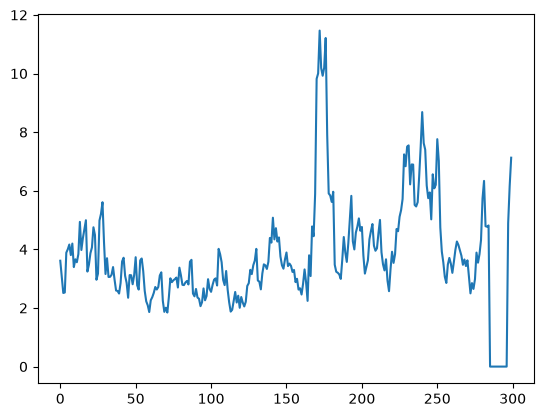

In [19]:
plt.plot(friedvbi)

In [20]:
intfile = np.load('/Users/coletamburri/Desktop/DKIST_August2024_Flare_RefResponse_FirstDraft/intensityarr.npz')
intfile2 = np.load('/Users/coletamburri/Desktop/DKIST_August2024_Flare_RefResponse_FirstDraft/intensityarr2.npz')

pix_to_arcsec = 0.017
arcsec_to_km=727
km_to_Mm = 0.001
choicemap = 'coolwarm'

In [21]:
intavginterps2 = intfile['intavginterps2']
intavginterps3 = intfile2['intavginterps2']

In [22]:
l=np.shape(intavginterps3)[1]

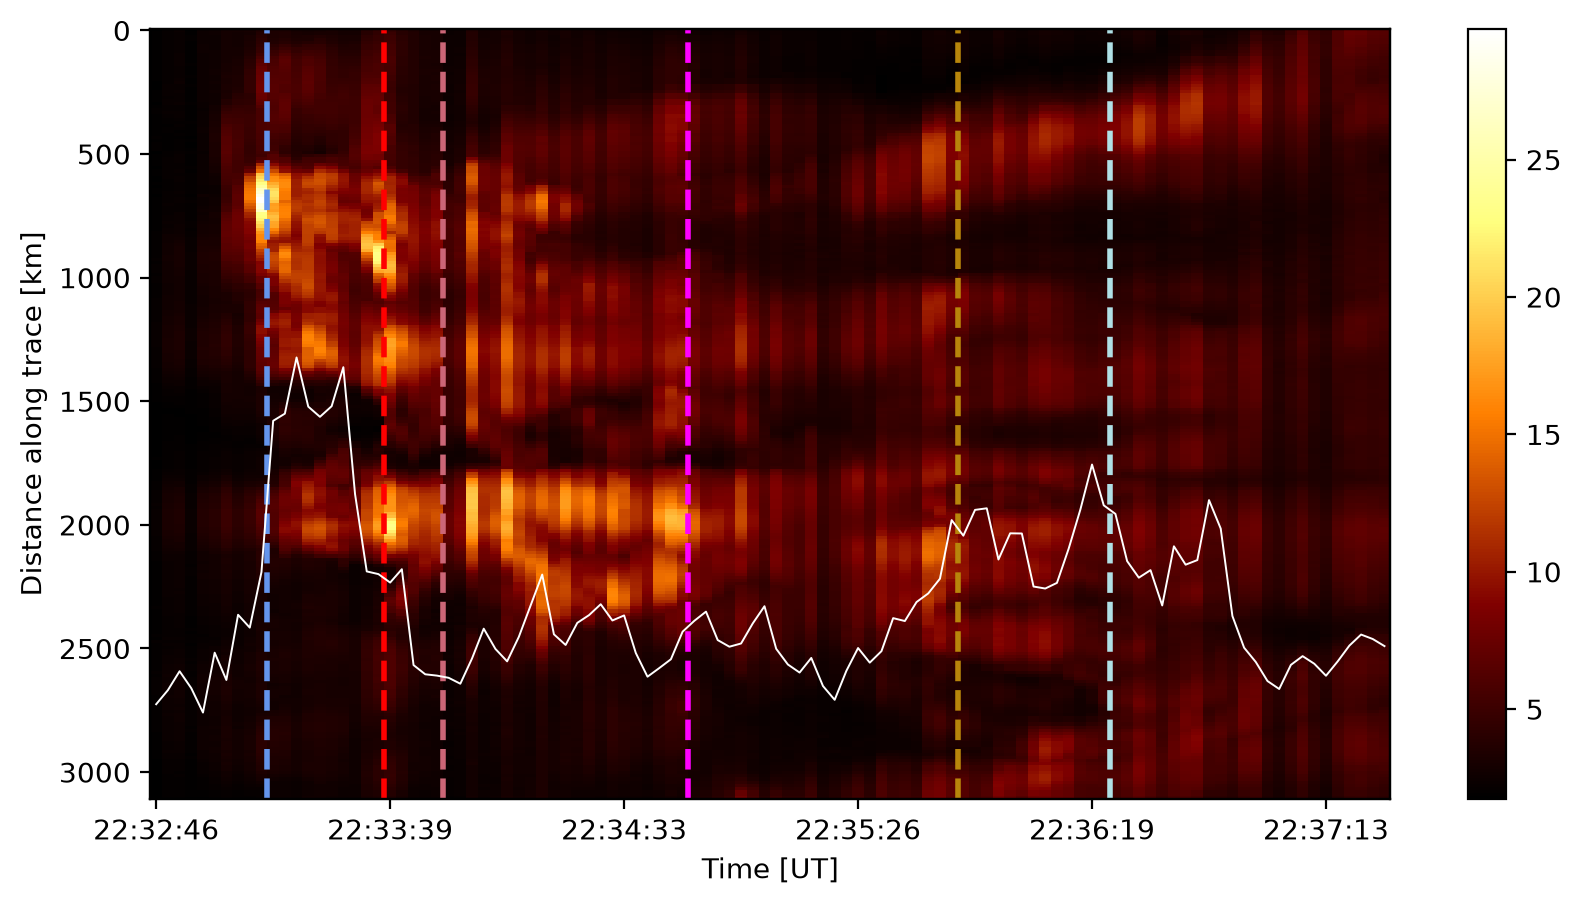

In [23]:
fig,ax=plt.subplots(dpi=200,figsize=(10,5))
im=ax.pcolormesh(np.arange(106),np.arange(l)*pix_to_arcsec*arcsec_to_km,np.transpose(intavginterps3[160:266]/1e4),cmap='afmhot')
ax2=ax.twinx()
ax2.plot(friedvbi[160:266],color='white',linewidth=0.7)
ax2.set_ylim(0,20)
ax2.set_yticks([])
ax.invert_yaxis()
fig.colorbar(im)
ax.axvline(9.5,c='cornflowerblue',linewidth=2,linestyle='dashed')
ax.axvline(19.5,c='red',linewidth=2,linestyle='dashed')
ax.axvline(24.5,c='#CC6677',linewidth=2,linestyle='dashed')
ax.axvline(45.5,c='magenta',linewidth=2,linestyle='dashed')
ax.axvline(68.5,c='darkgoldenrod',linewidth=2,linestyle='dashed')
ax.axvline(81.5,c='powderblue',linewidth=2,linestyle='dashed')
ax.set_xlabel('Time [UT]')
ax.set_ylabel('Distance along trace [km]')
ax.set_xticks([0,20,40,60,80,100],[onlytimevbi[160],onlytimevbi[160+20],onlytimevbi[160+40],onlytimevbi[160+60],onlytimevbi[160+80],onlytimevbi[160+100]])

In [24]:
xarray = np.asarray(np.arange(l)*pix_to_arcsec*arcsec_to_km)
xarray[40]

np.float64(494.36)

In [25]:
#gradient descent, find minimum positions on either side of a peak
def find_maxmin(x,peaks):
    lowinds=[]
    highinds=[]
    for peak in peaks:
        #find leftind
        l=0
        minimum = x[peak]
        newmin = x[peak-l]

        while newmin < minimum or newmin==minimum:
            minimum=newmin.copy()
            if l == peak+3:
                break

            newmin = x[peak-l]
            l+=1
        lowind=peak-l-2
        
        #find rightind
        m=0
        minimum = x[peak]
        newmin = x[peak+m]

        while newmin < minimum or newmin==minimum:
            minimum=newmin.copy()
            if peak+m+3 == len(x):
                break
            newmin = x[peak+m]
            m+=1  
        highind=peak+m+2

        lowinds.append(lowind)
        highinds.append(highind)
    return lowinds, highinds
            
def gaussian(x, a, mean, sigma, background,m):
    return background + m*x + a * np.exp(-(x - mean)**2 / (2 * sigma**2))

def find_widths_errors(x,peaks,intarr,lowinds,highinds):
    peak_params = []
    peak_errors = []
    i=0
    for peak in peaks:
        lowind = lowinds[i]
        highind = highinds[i]
        left = max(0, lowind)
        right = min(len(x), highind)

        x_fit = x[left:right]
        y_fit = intarr[left:right]
        backg = np.mean([y_fit[0], y_fit[-1]])
        mg = (y_fit[-1] - y_fit[0]) / (x_fit[-1] - x_fit[0])
        # Initial guess: amplitude, peak position, width
        guess = [intarr[peak], x[peak], 200,backg,mg]
        # Fit Gaussian
        try:
            popt, pcov = curve_fit(
                gaussian,
                x_fit,
                y_fit,
                p0=guess,
                bounds=(
                    [-np.inf, -np.inf, 0, -np.inf, -np.inf],
                    [ np.inf,  np.inf, np.inf,  np.inf,  np.inf]
                )
)
            perr = np.sqrt(np.diag(pcov))
            
            fwhm = 2 * np.sqrt(2 * np.log(2)) * popt[2]
            fwhm_error = 2 * np.sqrt(2 * np.log(2)) * perr[2]
            
            peak_params.append(fwhm)
            peak_errors.append(fwhm_error)
        except RuntimeError:
            # Fit failed
            peak_params.append(np.nan)
            peak_errors.append(np.nan)
        i+=1
    return peak_params, peak_errors

In [37]:
print(lowinds)
print(highinds)
print(peakwidths)

[np.int64(11), np.int64(38), np.int64(81), np.int64(117), np.int64(142), np.int64(190), np.int64(216)]
[np.int64(47), np.int64(59), np.int64(99), np.int64(140), np.int64(198), np.int64(224), np.int64(251)]
[10.36091269  4.76549658 18.92243197  8.60949476 26.84047242 11.8651664
 20.53593065]


In [39]:
print(len(intavginterps3))
print(len(friedvbi))

300
300


/var/folders/zv/_lmn_hx54rx33p0kc27kzf780000gn/T/ipykernel_21713/703796796.py:42: RuntimeWarning: All-NaN slice encountered
  nopeaksuncertain0[i]=allpeaks[i]*np.nanmedian(allpeakerrors[i]/allpeakwidths[i])


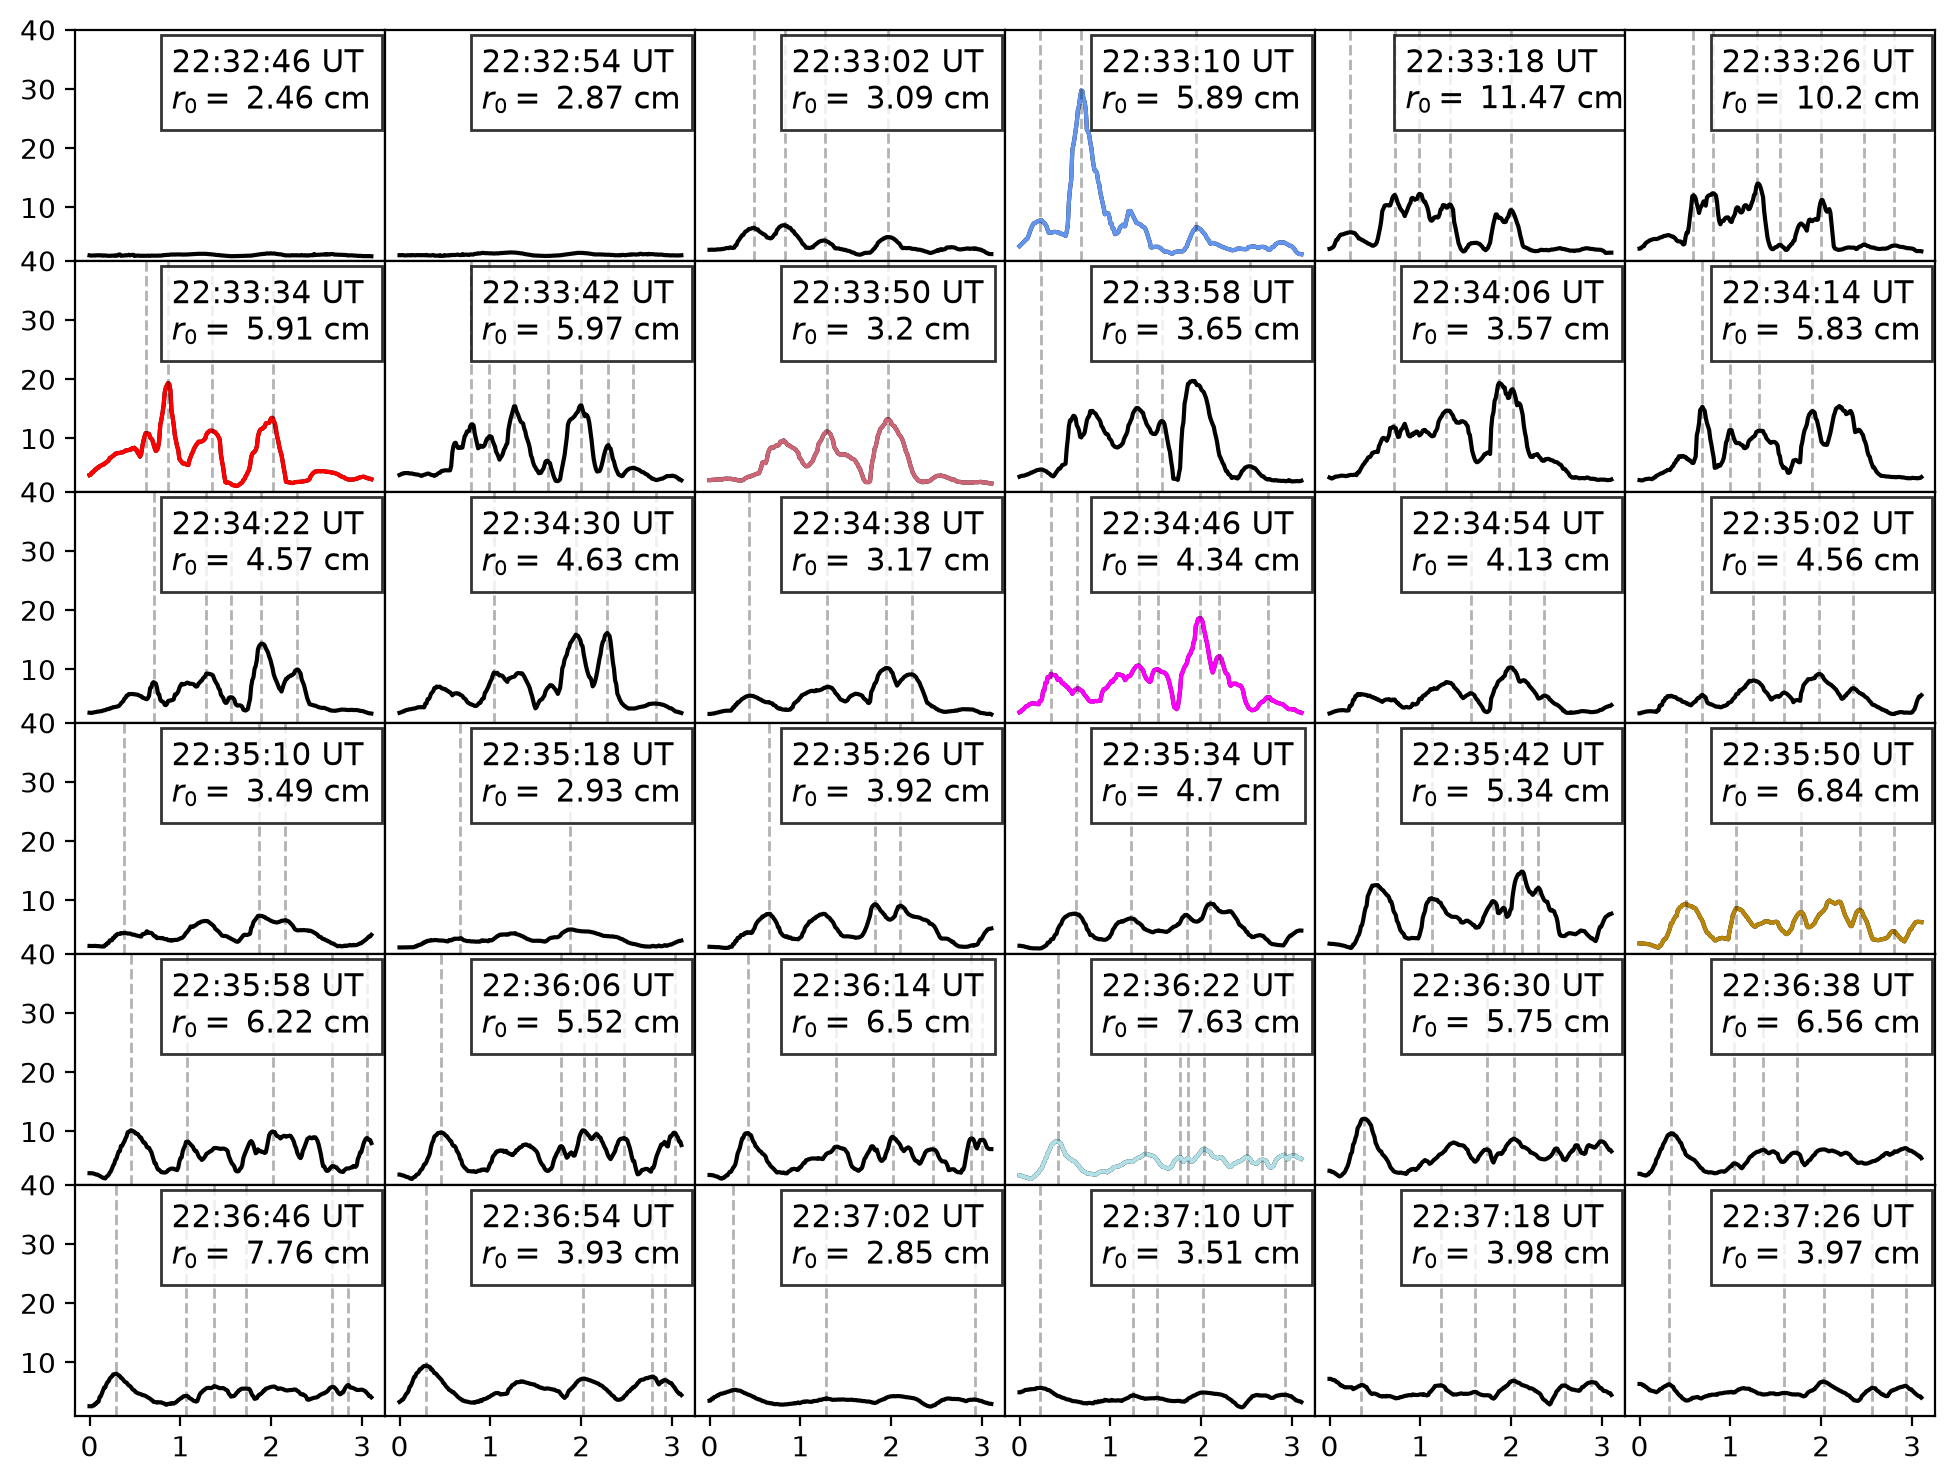

In [40]:
prom=0.05
allpeaks = np.full((36),np.nan)
allpeakslist = np.full((36,25),np.nan)
allpeakwidths = np.full((36,25),np.nan)
allpeakwidths1 = np.full((36,25),np.nan)
allpeakerrors = np.full((36,25),np.nan)
frieds = []
times = []
nopeaksuncertain0 = np.full((36),np.nan)

for i in range(int(len(intavginterps3[160:266])/3)+1):
    array = intavginterps3[160+3*i,:]/1e4
    times.append(onlytimevbi[160+3*i])
    if i > 1:
        smallarr = array
        xarray = np.asarray(np.arange(l)*pix_to_arcsec*arcsec_to_km)
        peaks,proms = find_peaks((smallarr-np.nanmin(smallarr))/(np.nanmax(smallarr)-np.nanmin(smallarr)),prominence=prom)
        peakwidths,widthheights,leftips,rightips = peak_widths((smallarr-np.nanmin(smallarr))/(np.nanmax(smallarr)-np.nanmin(smallarr)),peaks,rel_height=0.5)
        lowinds,highinds = find_maxmin(smallarr,peaks)
        peak_params,peak_errors = find_widths_errors(xarray,peaks,smallarr,lowinds,highinds)

        allpeakslist[i,0:len(peaks)] = peaks
        allpeaks[i] = len(peaks)
        allpeakwidths[i,0:len(peaks)] = peak_params
        allpeakerrors[i,0:len(peaks)] = peak_errors
        

    frieds.append(friedvbi[160+3*i])

for i in range(len(allpeakwidths)):
    for j in range(len(allpeakwidths[i,:])):
        if np.isnan(allpeakwidths[i,j]) and not np.isnan(allpeakslist[i,j]):
            allpeaks[i]-=1
            allpeakslist[i,j] = np.nan
        elif not np.isnan(allpeakwidths[i,j]):
            if allpeakerrors[i,j] > .5 * allpeakwidths[i,j]:
                allpeakerrors[i,j] = np.nan
                allpeakwidths[i,j] = np.nan
                allpeaks[i]-=1
                allpeakslist[i,j] = np.nan

    nopeaksuncertain0[i]=allpeaks[i]*np.nanmedian(allpeakerrors[i]/allpeakwidths[i])

fig,ax=plt.subplots(6,6,dpi=200,figsize=(12,9))
axes=ax.ravel()
props = dict(edgecolor='black',facecolor='white',alpha=0.8)
for i in range(int(len(intavginterps3[160:266])/3)+1):
    array = intavginterps3[160+3*i,:]/1e4
    smallarr = array
    xarray = np.asarray(np.arange(l)*pix_to_arcsec*arcsec_to_km)
    axes[i].plot(xarray,array,c='black')
    if 3*i ==9:
        axes[i].plot(xarray,array,c='cornflowerblue')
    if 3*i ==18:
        axes[i].plot(xarray,array,c='red')
    if 3*i ==24:
        axes[i].plot(xarray,array,c='#CC6677')
    if 3*i ==45:
        axes[i].plot(xarray,array,c='magenta')
    if 3*i ==69:
        axes[i].plot(xarray,array,c='darkgoldenrod')
    if 3*i ==81:
        axes[i].plot(xarray,array,c='powderblue')
    text=onlytimevbi[160+3*i]+' UT\n'+r'$r_0=$ '+str(round(friedvbi[160+3*i],2))+' cm'
    if i == 4:
        axes[i].text(0.29, 0.93, text, transform=axes[i].transAxes, 
            fontsize=11, verticalalignment='top', bbox=props)
    else:
        axes[i].text(0.31, 0.93, text, transform=axes[i].transAxes, 
            fontsize=11, verticalalignment='top', bbox=props)

    peaks = allpeakslist[i]
    if i > 1:
        for j in peaks:
            if j > 0:
                axes[i].axvline(xarray[int(j)],linestyle='dashed',color='black',alpha=0.3,linewidth=1)
    axes[i].set_ylim([1,40])

    if i%6 > 0:
        axes[i].set_yticks([])

    if i < 29:
        axes[i].set_xticks([])
    else:
        axes[i].set_xticks([0,1000,2000,3000],labels=['0','1','2','3'])


fig.subplots_adjust(wspace=0, hspace=0)

In [41]:
allpeaks

array([nan, nan,  4.,  3.,  5.,  7.,  4.,  7.,  2.,  4.,  4.,  4.,  5.,
        4.,  4.,  7.,  3.,  5.,  3.,  2.,  3.,  4.,  6.,  5.,  5.,  6.,
        6.,  9.,  6.,  5.,  6.,  4.,  3.,  5.,  6.,  5.])

2026-09-28 16:38:17 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-28 16:38:17 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-28 16:38:17 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-28 16:38:17 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-09-28 16:38:17 - matplotlib.categor

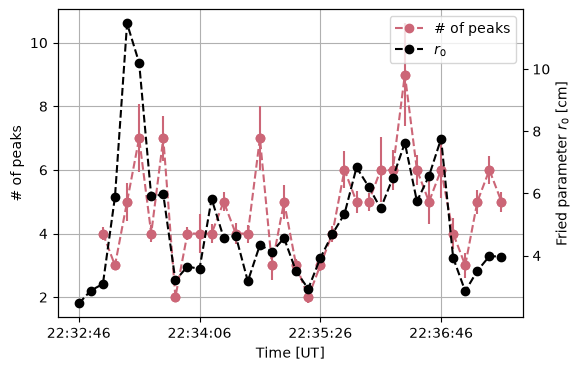

In [42]:
fig,ax=plt.subplots(1,1,dpi=100,figsize=(6,4))
ax1=ax.twinx()
lns1 = ax.plot(times,allpeaks,marker='o',linestyle='--',label='# of peaks',c='#CC6677')
ax.errorbar(times,allpeaks,yerr=nopeaksuncertain0,c='#CC6677',fmt='o')

#ax1.errorbar(np.arange(len(medians)),medians,stds,c='#CC6677',marker='o',linestyle='--')
ax.set_xlabel('Time [UT]')
ax.set_ylabel('# of peaks')
ax1.set_ylabel('Fried parameter $r_0$ [cm]')
lns2 = ax1.plot(times,frieds,c='black',marker='o',linestyle='--',label='$r_0$')
lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax.legend(lns,labs)
ax.grid()
ax.set_xticks([0,10,20,30])

In [49]:
allpeaks_all = np.full((106),np.nan)
allpeakslist_all = np.full((106,25),np.nan)
allpeakwidths_all = np.full((106,25),np.nan)
allpeakwidths1_all = np.full((106,25),np.nan)
allpeakerrors_all = np.full((106,25),np.nan)
frieds_all = []
times_all = []
nopeaksuncertain = np.full((106),np.nan)

for i in range(int(len(intavginterps3[160:266]))):
    array = intavginterps3[160+i,:]/1e4
    times_all.append(onlytimevbi[160+i])
    if i > 1:
        smallarr = array
        xarray = np.asarray(np.arange(l)*pix_to_arcsec*arcsec_to_km)
        peaks,proms = find_peaks((smallarr-np.nanmin(smallarr))/(np.nanmax(smallarr)-np.nanmin(smallarr)),prominence=prom)
        lowinds,highinds = find_maxmin(smallarr,peaks)
        peak_params,peak_errors = find_widths_errors(xarray,peaks,smallarr,lowinds,highinds)

        allpeakslist_all[i,0:len(peaks)] = peaks
        allpeaks_all[i] = len(peaks)
        allpeakwidths_all[i,0:len(peaks)] = peak_params
        allpeakerrors_all[i,0:len(peaks)] = peak_errors
        
    #else:
    #    allpeaks_all.append(0)
    #    nopeaksuncertain.append(0)
    #    allpeakwidths_all.append(np.nan)
    #    allpeakerrors_all.append(np.nan)
    #    allpeakslist_all.append([0])

    frieds_all.append(friedvbi[160+i])

for i in range(len(allpeakwidths_all)):
    for j in range(len(allpeakwidths_all[i,:])):
        if np.isnan(allpeakwidths_all[i,j]) and not np.isnan(allpeakslist_all[i,j]):
            allpeaks_all[i]-=1
            allpeakslist_all[i,j] = np.nan

        elif not np.isnan(allpeakwidths_all[i,j]):
            if allpeakerrors_all[i,j] > .5 * allpeakwidths_all[i,j]:
                allpeakerrors_all[i,j] = np.nan
                allpeakwidths_all[i,j] = np.nan
                allpeaks_all[i]-=1
                allpeakslist_all[i,j] = np.nan

    nopeaksuncertain[i]=allpeaks_all[i]*np.nanmedian(allpeakerrors_all[i]/allpeakwidths_all[i])

/var/folders/zv/_lmn_hx54rx33p0kc27kzf780000gn/T/ipykernel_21713/851617258.py:47: RuntimeWarning: All-NaN slice encountered
  nopeaksuncertain[i]=allpeaks_all[i]*np.nanmedian(allpeakerrors_all[i]/allpeakwidths_all[i])


In [53]:
len(allpeaks_all)

106

In [52]:
len(frieds_all)

106

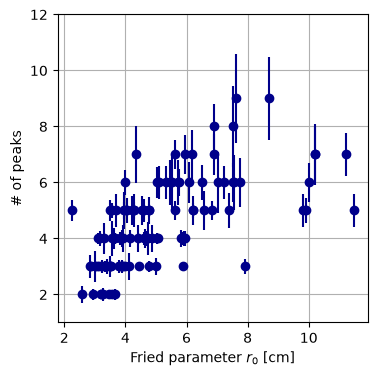

In [55]:
fig,ax=plt.subplots(dpi=100,figsize=(4,4));
ax.errorbar(frieds_all[2:],allpeaks_all[2:],yerr=nopeaksuncertain[2:],fmt='o',c='darkblue')
ax.set_xlabel('Fried parameter $r_0$ [cm]')
ax.set_ylabel('# of peaks')
ax.set_ylim([1,12])
ax.grid()

In [56]:
from scipy.stats import spearmanr

In [57]:
spearmanr(frieds_all[2:],allpeaks_all[2:],nan_policy='omit')

SignificanceResult(statistic=np.float64(0.7031370789776457), pvalue=np.float64(8.698548194368299e-17))

In [58]:
allpeaks_all

array([nan, nan,  4.,  3.,  5.,  3.,  4.,  5.,  3.,  3.,  5.,  6.,  5.,
        7.,  5.,  7.,  7.,  3.,  4.,  4.,  5.,  7.,  2.,  3.,  2.,  3.,
        3.,  4.,  4.,  3.,  4.,  5.,  4.,  4.,  5.,  3.,  5.,  5.,  4.,
        4.,  3.,  3.,  4.,  3.,  4.,  7.,  5.,  4.,  3.,  5.,  5.,  5.,
        3.,  4.,  3.,  2.,  2.,  2.,  2.,  3.,  3.,  3.,  4.,  4.,  4.,
        6.,  6.,  6.,  6.,  5.,  6.,  6.,  5.,  8.,  7.,  6.,  6.,  7.,
        6.,  8.,  9.,  9.,  5.,  7.,  6.,  4.,  6.,  5.,  6.,  5.,  6.,
        6.,  4.,  4.,  2.,  3.,  3.,  3.,  5.,  5.,  2.,  5.,  6.,  5.,
        4.,  5.])

In [59]:
import numpy.ma as ma

np.corrcoef(allpeaks_all[2:],frieds_all[2:])[0,1]**2

np.float64(0.4006159807528248)

In [202]:
allpeakwidths[2][0]

np.float64(186.7290987971039)

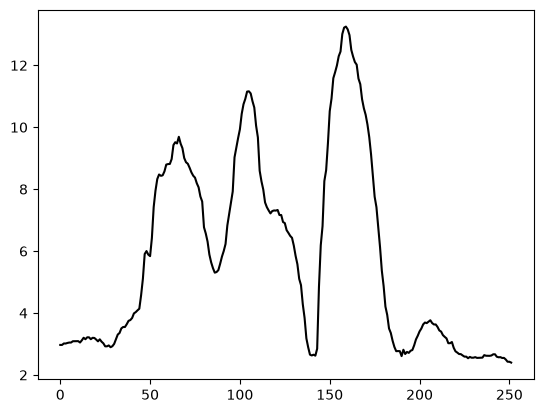

In [23]:
i= 8
fig,ax=plt.subplots()
ax.plot(intavginterps3[160+3*i,:]/1e4,c='black')

In [25]:
from scipy.signal import find_peaks
samp =intavginterps3[160+3*i,:]/1e4
print(find_peaks(samp,prominence=3))

(array([ 66, 105, 159]), {'prominences': array([ 4.38685179,  8.26386786, 10.62789321]), 'left_bases': array([ 28,  28, 142]), 'right_bases': array([ 86, 142, 251])})


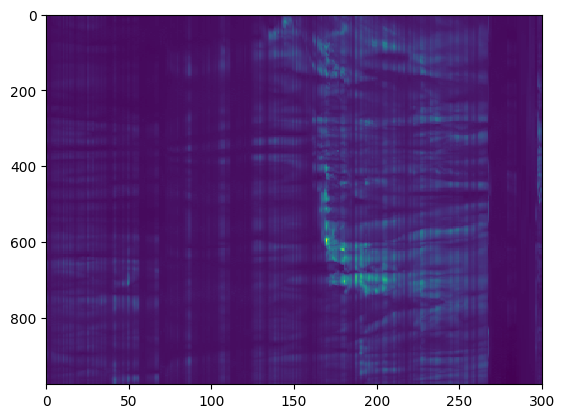

In [5]:
fig,ax=plt.subplots();
ax.pcolormesh(np.transpose(intavginterps2))
ax.invert_yaxis()

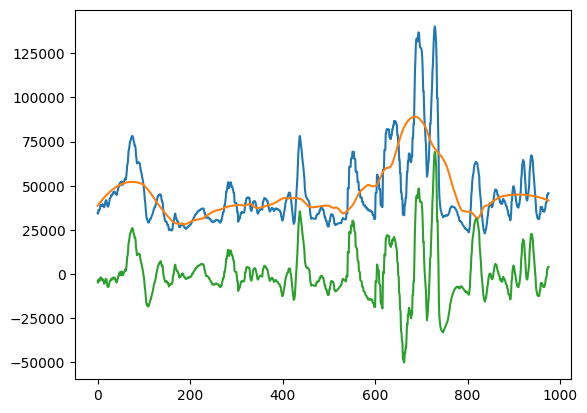

In [6]:
sample = intavginterps2[200]
smooth = savgol_filter(sample,200,2)

plt.plot(sample)
plt.plot(smooth)
plt.plot(sample-smooth)

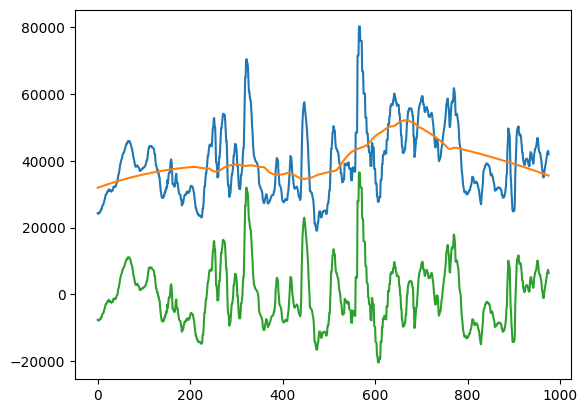

In [7]:
sample = intavginterps2[250]
smooth = savgol_filter(sample,400,2)

plt.plot(sample)
plt.plot(smooth)
plt.plot(sample-smooth)

In [8]:
def psd_func(intensityarr,choice = 'variance',normpsd=0,savgol_window = 200, savgol_polyorder=2):
    all_freq = []
    psds = []
    n = np.shape(intensityarr)[1]
    n+=100
    dx=1
    
    for i in range(np.shape(intensityarr)[0]):
        
        chintensities0 = np.asarray(intensityarr[i])

        smooth = savgol_filter(chintensities0,savgol_window,savgol_polyorder)

        chintensities1=chintensities0-smooth

        chintensities = np.pad(chintensities1, (50, 50), mode='constant')

        # detrend intensities
        
        if choice == 'variance':
            selection = (chintensities - np.nanmean(chintensities))/np.nanstd(chintensities)
        elif choice == 'nothing':
            selection = chintensities
        elif choice == 'L2':
            selection = chintensities/np.linalg.norm(chintensities)
        elif choice == 'max':
            selection = chintensities/np.nanmax(chintensities)

        
        wind = np.hanning(n)
        xw1 = selection*wind
        fft_result1 = np.fft.fft(xw1)
        freqs = np.fft.fftfreq(n,d=dx)
        freqresult = np.arange(len(chintensities) // 2 , dtype=float) / (n - 0)
        freqresult[0] = freqresult[1]/2
        mask = freqs >= 0 
        all_freq.append(freqs[mask])
        #psd1 = (np.abs(fft_result1)**2)/n # my og norm
        const = 2.67038 / (1/len(chintensities)) # from ryan norm
        psd1 = 2*(np.abs(fft_result1)**2) * const # from ryan norm
        psd1 = psd1[mask]
        if normpsd == 1:
            psd1 = psd1/np.sum(psd1)
        psds.append(psd1)


    all_psdarr = np.array(psds)
    all_freqarr = np.array(all_freq)

    return all_psdarr, all_freqarr,freqresult

(25.0, 500.0)

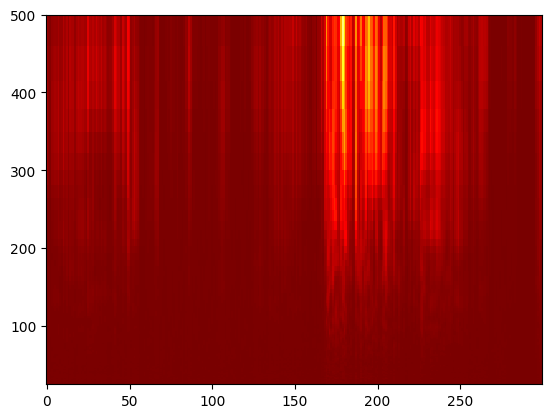

In [9]:
# test - no scaling, compare 1d ffts:
choicemap='hot'
psd_max, freq_max,freqresult = psd_func(intavginterps3,choice='nothing',normpsd=0,savgol_window=100,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100);
# ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],\
#               gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max[:,1:],.1)),axis=1,sigma=1),\
#                                 axis=0,sigma=.8),cmap=choicemap)
#ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,1:])),axis=0,sigma=2),cmap=choicemap,vmin=-7e3,vmax=3.2e4)
ax.pcolormesh(np.arange(300),727*0.017/freqresult,gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,:])),axis=0,sigma=1.5),cmap=choicemap,vmin=-2e7,vmax=1e8)
ax.set_ylim([25,500])


In [10]:
QS_avg = np.mean(psd_max[42:52,:],axis=0)

In [93]:
flare_avg = np.mean(psd_max[165:175,:],axis=0)

(0.0, 500.0)

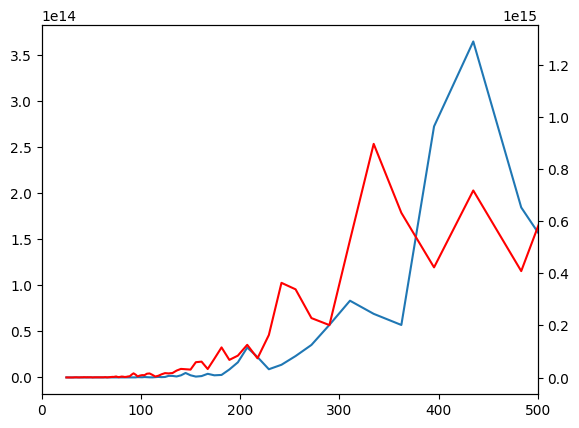

In [95]:
fig,ax=plt.subplots();
ax2=ax.twinx()
ax.plot(727*0.017/freqresult,QS_avg,label='QS')
ax2.plot(727*0.017/freqresult,flare_avg,label='flare',color='red')
ax.set_xlim([0,500])

In [ ]:
# I think this is not showing anything except fried parameter increase.

Text(0.5, 0, 'Time [UT]')

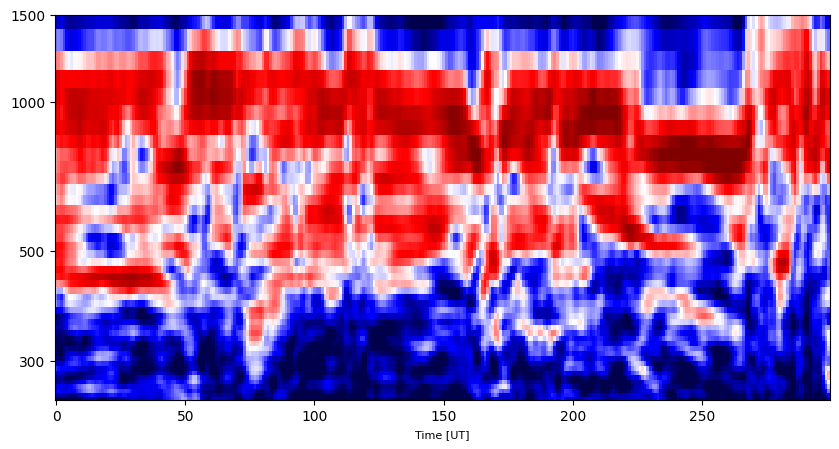

In [153]:
# now make this plot but accounting for variance:
# test - no scaling, compare 1d ffts:
choicemap='seismic'
psd_max, freq_max,freqresult = psd_func(intavginterps2,choice='variance',normpsd=1,savgol_window=200,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100,figsize=(10,5));
ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freqresult,\
                           gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max,.1)),\
                                                               axis=1,sigma=1),axis=0,sigma=1),cmap=choicemap,vmin=.5,vmax=.8)
ax.set_yscale('log')
ax.set_ylim([250,1500]) 
ax.set_yticks([300,500, 1000, 1500])
ax.set_yticklabels(['300','500', '1000','1500'])

ax.minorticks_off()
ax.set_xlabel('Time [UT]',fontsize=8)


Text(0.5, 0, 'Time [UT]')

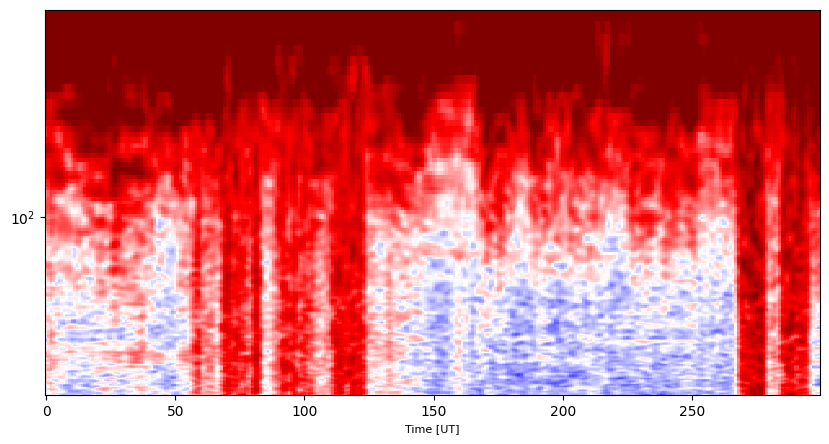

In [158]:
# test - no scaling, compare 1d ffts:
choicemap='seismic'
psd_max, freq_max,freqresult = psd_func(intavginterps3,choice='variance',normpsd=1,savgol_window=200,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100,figsize=(10,5));
ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freqresult,\
                           gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max,.1)),\
                                                               axis=1,sigma=1),axis=0,sigma=1),cmap=choicemap,vmin=.1,vmax=.6)
ax.set_yscale('log')
ax.set_ylim([25,500]) 
#ax.set_yticks([300,500, 1000, 1500])
#ax.set_yticklabels(['300','500', '1000','1500'])

ax.minorticks_off()
ax.set_xlabel('Time [UT]',fontsize=8)

(25.0, 500.0)

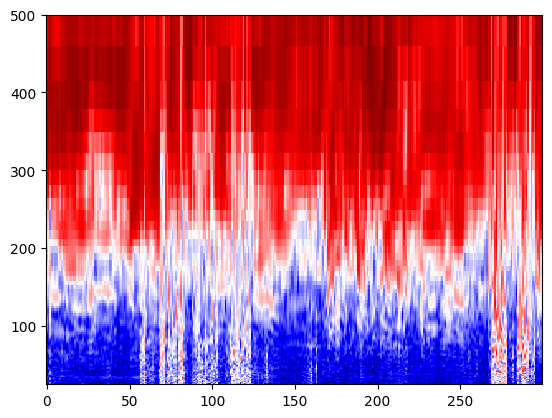

In [113]:
# test first for just max divide:
choicemap='seismic'
psd_max, freq_max,freqresult = psd_func(intavginterps3,choice='variance',normpsd=0,savgol_window=100,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100);
# ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],\
#               gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max[:,1:],.1)),axis=1,sigma=1),\
#                                 axis=0,sigma=.8),cmap=choicemap)
#ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,1:])),axis=0,sigma=2),cmap=choicemap,vmin=-7e3,vmax=3.2e4)
ax.pcolormesh(np.arange(300),727*0.017/freqresult,gaussian_filter1d(np.transpose(np.power(psd_max[:,:],.1)),axis=0,sigma=1.5),cmap=choicemap)#,vmin=-2,vmax=8)#,vmin=-2e7,vmax=1e8)
ax.set_ylim([25,500])



(25.0, 100.0)

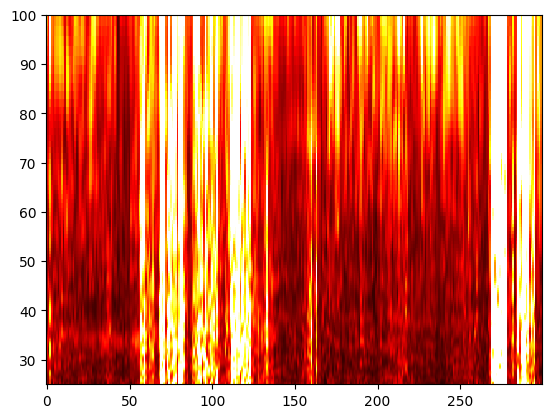

In [75]:
# test first for just max divide:
choicemap='hot'
psd_max, freq_max,freqresult = psd_func(intavginterps3,choice='variance',normpsd=0,savgol_window=100,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100);
# ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],\
#               gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max[:,1:],.1)),axis=1,sigma=1),\
#                                 axis=0,sigma=.8),cmap=choicemap)
#ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,1:])),axis=0,sigma=2),cmap=choicemap,vmin=-7e3,vmax=3.2e4)
ax.pcolormesh(np.arange(300),727*0.017/freqresult,gaussian_filter1d(gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,:])),axis=0,sigma=2),axis=0,sigma=2),cmap=choicemap,vmin=0.1,vmax=300)#,vmin=-2e7,vmax=1e8)
ax.set_ylim([25,100])

(25.0, 500.0)

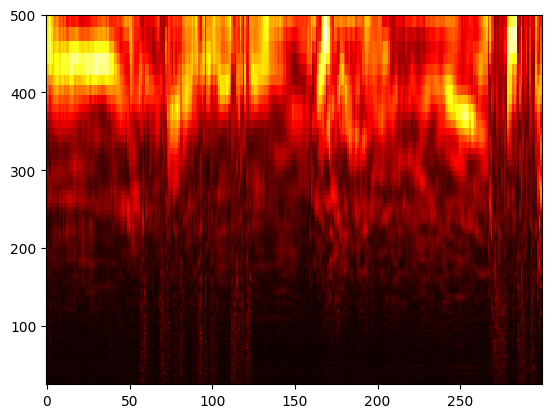

In [63]:
# test first for just max divide:
choicemap='hot'
psd_max, freq_max,freqresult = psd_func(intavginterps2,choice='variance',normpsd=0,savgol_window=100,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100);
# ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],\
#               gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max[:,1:],.1)),axis=1,sigma=1),\
#                                 axis=0,sigma=.8),cmap=choicemap)
#ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,1:])),axis=0,sigma=2),cmap=choicemap,vmin=-7e3,vmax=3.2e4)
ax.pcolormesh(np.arange(300),727*0.017/freqresult,gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,:])),axis=0,sigma=1.5),cmap=choicemap)#,vmin=-1e7,vmax=1e8)
ax.set_ylim([25,500])


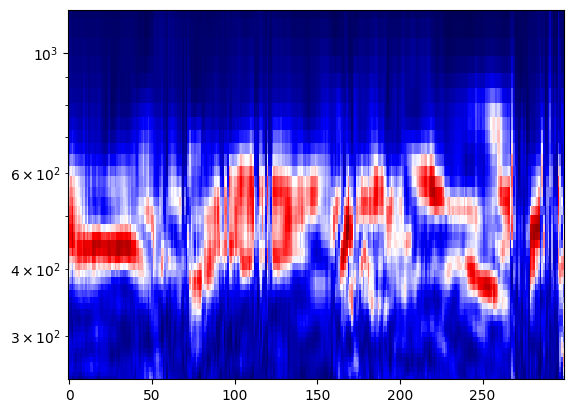

In [122]:
# test first for just max divide:
choicemap='seismic'
psd_max, freq_max,freqresult = psd_func(intavginterps2,choice='variance',normpsd=0,savgol_window=100,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100);
# ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],\
#               gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max[:,1:],.1)),axis=1,sigma=1),\
#                                 axis=0,sigma=.8),cmap=choicemap)
#ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,1:])),axis=0,sigma=2),cmap=choicemap,vmin=-7e3,vmax=3.2e4)
ax.pcolormesh(np.arange(300),727*0.017/freqresult,gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,:])),axis=0,sigma=1.5),cmap=choicemap)#,vmin=-1e7,vmax=1e8)
ax.set_ylim([250,1200])
ax.set_yscale('log')


In [ ]:
# test first for just max divide:
choicemap='hot'
psd_max, freq_max,freqresult = psd_func(intavginterps2,choice='variance',normpsd=0,savgol_window=100,savgol_polyorder=5)

fig,ax=plt.subplots(dpi=100);
# ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],\
#               gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max[:,1:],.1)),axis=1,sigma=1),\
#                                 axis=0,sigma=.8),cmap=choicemap)
#ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,1:])),axis=0,sigma=2),cmap=choicemap,vmin=-7e3,vmax=3.2e4)
ax.pcolormesh(np.arange(300),727*0.017/freqresult,gaussian_filter1d(np.transpose(np.sqrt(psd_max[:,:])),axis=0,sigma=1.5),cmap=choicemap)#,vmin=-1e7,vmax=1e8)
ax.set_ylim([25,500])

1. less detrending to look at smaller scale structures? Maybe not for this paper if no result but good to check
2. average over a few time steps and compare pre flare to flare

In [42]:
print(727*0.017/freqresult)

[8700.736      4350.368      2175.184      1450.12266667 1087.592
  870.0736      725.06133333  621.48114286  543.796       483.37422222
  435.0368      395.488       362.53066667  334.64369231  310.74057143
  290.02453333  271.898       255.904       241.68711111  228.96673684
  217.5184      207.16038095  197.744       189.14643478  181.26533333
  174.01472     167.32184615  161.12474074  155.37028571  150.01268966
  145.01226667  140.33445161  135.949       131.82933333  127.952
  124.29622857  120.84355556  117.57751351  114.48336842  111.54789744
  108.7592      106.10653659  103.58019048  101.17134884   98.872
   96.67484444   94.57321739   92.56102128   90.63266667   88.78302041
   87.00736      85.30133333   83.66092308   82.08241509   80.56237037
   79.0976       77.68514286   76.32224561   75.00634483   73.73505085
   72.50613333   71.3175082    70.16722581   69.05346032   67.9745
   66.92873846   65.91466667   64.93086567   63.976        63.04881159
   62.14811429   61.27278

(0.0, 500.0)

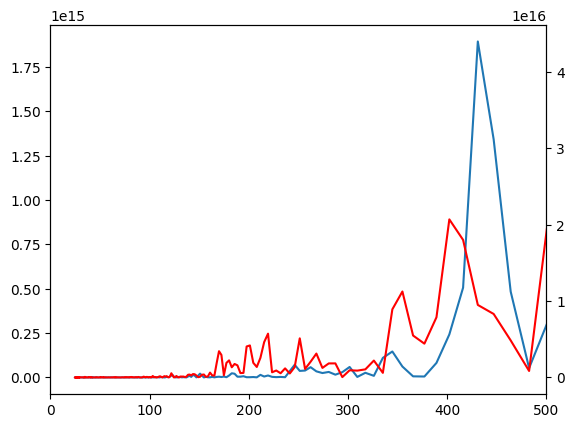

In [270]:
fig,ax=plt.subplots();
ax.plot(arcsec_to_km*pix_to_arcsec*1/freqresult,psd_max[31,:])
ax2=ax.twinx()
ax2.plot(arcsec_to_km*pix_to_arcsec*1/freqresult,psd_max[180,:],c='red')

ax.set_xlim(0,500)

(90, 2000)

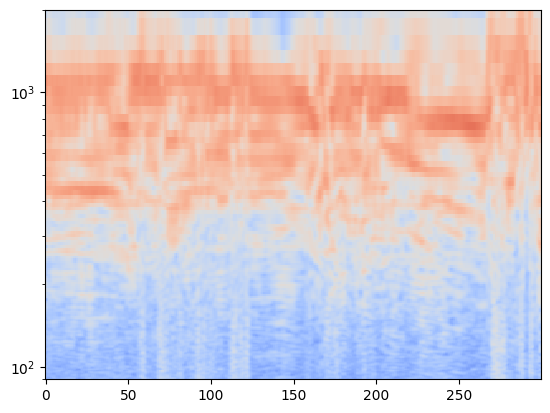

In [32]:
# just max divide and psd norm:

psd_max, freq_max = psd_func(intavginterps2,choice='max',normpsd=1)

fig,ax=plt.subplots(dpi=100);
ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_max[0,1:],\
              gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_max[:,1:],.1)),axis=1,sigma=1),\
                                axis=0,sigma=.8),cmap=choicemap,vmin=0.1,vmax=1)
ax.set_yscale('log')
ax.set_ylim([90,2000])


(90, 2000)

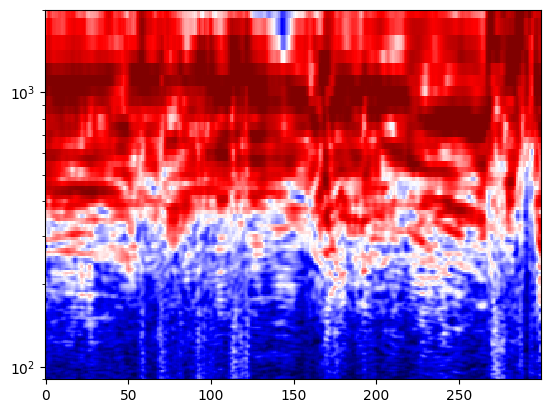

In [117]:
# variance:

psd_var,freq_var = psd_func(intavginterps2)

fig,ax=plt.subplots(dpi=100);
ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_var[0,1:],\
              gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_var[:,1:],.1)),axis=1,sigma=1),\
                                axis=0,sigma=.8),cmap=choicemap,vmin=0.5,vmax=1.3)
ax.set_yscale('log')
ax.set_ylim([90,2000])


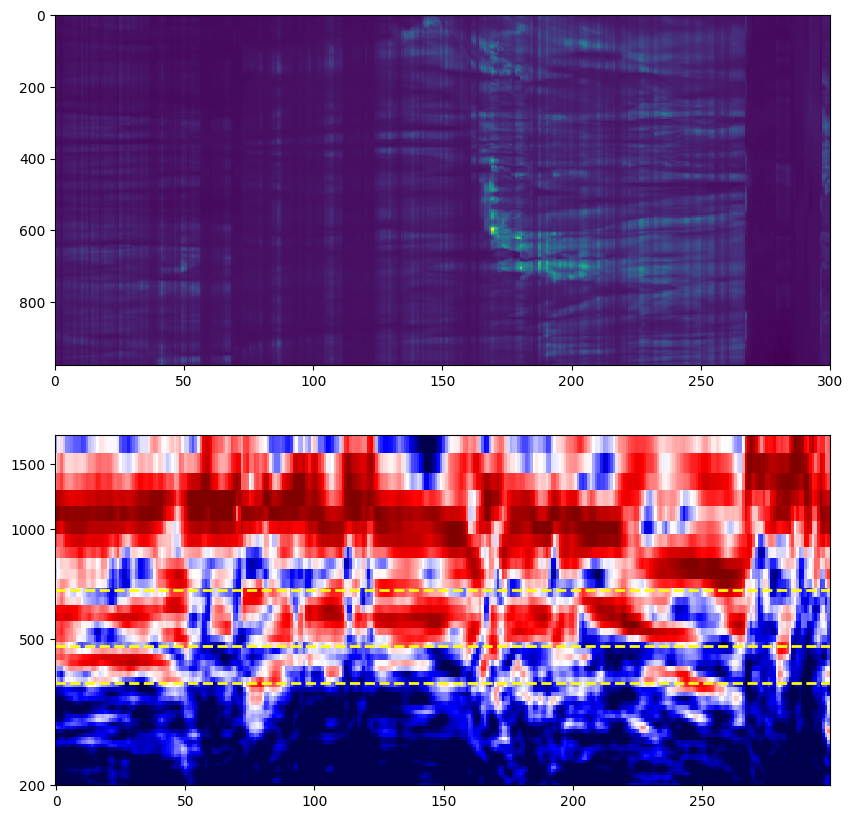

In [152]:
#max scaling
choicemap = 'seismic'
psd_L2,freq_L2 = psd_func(intavginterps2,choice='max',normpsd=1)

fig,[ax0,ax]=plt.subplots(2,1,dpi=100,figsize=(10,10));

ax0.pcolormesh(np.transpose(intavginterps2))
ax0.invert_yaxis()

ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_L2[0,1:],\
              gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_L2[:,1:],.1)),axis=1,sigma=.8),\
                                axis=0,sigma=.8),cmap=choicemap,vmin=0.5,vmax=.8)
ax.set_yscale('log')
ax.set_ylim([200,1800])
ax.set_yticks([200,500, 1000, 1500])
# Optionally set labels
ax.set_yticklabels(['200','500', '1000','1500'])
ax.minorticks_off()
ax.axhline(480,c='yellow',linestyle='dashed',linewidth=2)
ax.axhline(680,c='yellow',linestyle='dashed',linewidth=2)
ax.axhline(380,c='yellow',linestyle='dashed',linewidth=2)


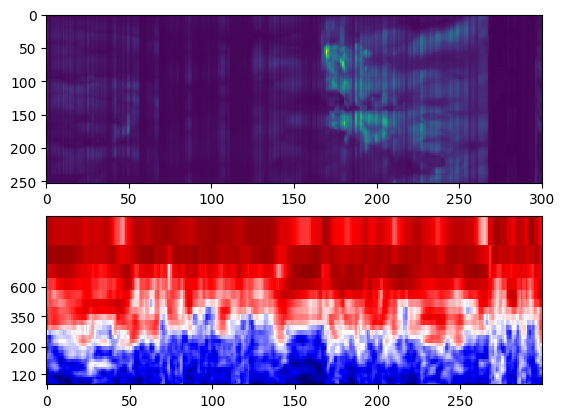

In [153]:
#max scaling

psd_L2_2,freq_L2_2 = psd_func(intavginterps3,choice='max',normpsd=1)

fig,[ax0,ax]=plt.subplots(2,1,dpi=100);

ax0.pcolormesh(np.transpose(intavginterps3))
ax0.invert_yaxis()

ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_L2_2[0,1:],\
              gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_L2_2[:,1:],.1)),axis=1,sigma=.8),\
                                axis=0,sigma=.8),cmap=choicemap,vmin=0.3,vmax=.9)
ax.set_yscale('log')
ax.set_ylim([100,2200])
ax.set_yticks([120,200, 350, 600])
# Optionally set labels
ax.set_yticklabels(['120','200', '350','600'])
ax.minorticks_off()
#ax.axhline(500,c='black',linestyle='dashed',linewidth=0.4)

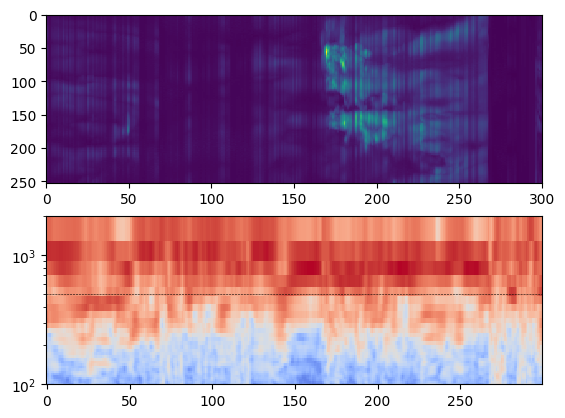

In [56]:
#variance scaling

psd_var_2,freq_var_2 = psd_func(intavginterps3,choice='variance',normpsd=1)

fig,[ax0,ax]=plt.subplots(2,1,dpi=100);

ax0.pcolormesh(np.transpose(intavginterps3))
ax0.invert_yaxis()

ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_var_2[0,1:],\
              gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_var_2[:,1:],.1)),axis=1,sigma=.8),\
                                axis=0,sigma=.8),cmap=choicemap)#,vmin=0.1,vmax=.6)
ax.set_yscale('log')
ax.set_ylim([100,2000])
ax.axhline(500,c='black',linestyle='dashed',linewidth=0.4)

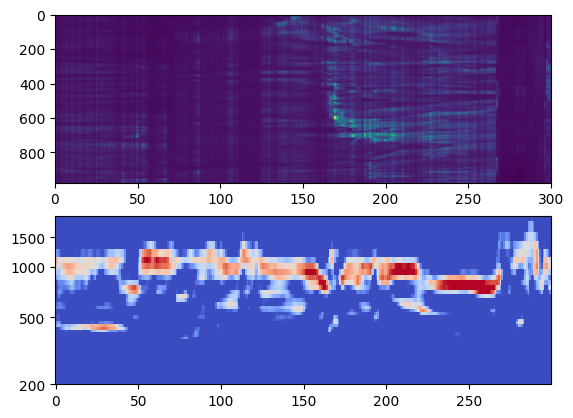

In [55]:
#no scaling

psd_nothing,freq_nothing = psd_func(intavginterps2,choice='nothing',normpsd=1)

fig,[ax0,ax]=plt.subplots(2,1,dpi=100);

ax0.pcolormesh(np.transpose(intavginterps2))
ax0.invert_yaxis()

ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_nothing[0,1:],\
              gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_nothing[:,1:],.1)),axis=1,sigma=1),\
                                axis=0,sigma=1),cmap=choicemap,vmin=0.7,vmax=.8)
ax.set_yscale('log')
ax.set_ylim([300,2000])
ax.set_yticks([200,500, 1000, 1500])
# Optionally set labels
ax.set_yticklabels(['200','500', '1000','1500'])
ax.minorticks_off()
#ax.axhline(500,c='black',linestyle='dashed',linewidth=0.4)
#ax.axhline(700,c='black',linestyle='dashed',linewidth=0.4)

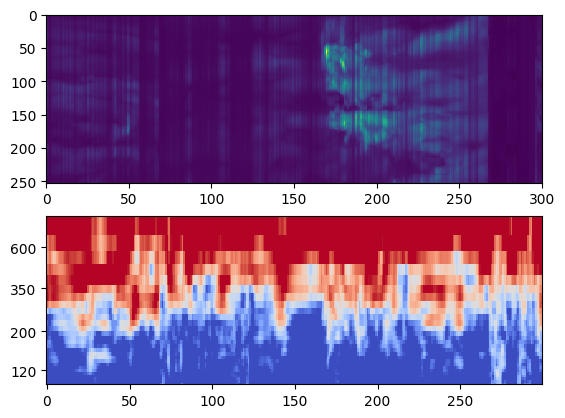

In [53]:
#no scaling

psd_nothing_2,freq_nothing_2 = psd_func(intavginterps3,choice='nothing',normpsd=1)

fig,[ax0,ax]=plt.subplots(2,1,dpi=100);

ax0.pcolormesh(np.transpose(intavginterps3))
ax0.invert_yaxis()

ax.pcolormesh(np.arange(300),arcsec_to_km*pix_to_arcsec*1/freq_nothing_2[0,1:],\
              gaussian_filter1d(gaussian_filter1d(np.transpose(np.power(psd_nothing_2[:,1:],.1)),axis=1,sigma=.8),\
                                axis=0,sigma=.8),cmap=choicemap,vmin=0.5,vmax=.75)
ax.set_yscale('log')
ax.set_ylim([100,900])
ax.set_yticks([120,200, 350, 600])
# Optionally set labels
ax.set_yticklabels(['120','200', '350','600'])
ax.minorticks_off()
#ax.axhline(500,c='black',linestyle='dashed',linewidth=0.4)